# 202 · Anytime Valid Inference: E-processes

Traditional GSD requires you to pre-specify the number of looks (e.g., $K=5$). If you "peek" at the data more often, you inflate the Type I error. 

**Anytime Valid Inference (AVI)** solves this using **E-processes** (like the **mSPRT**). You can monitor the data as often as you want—even after every single sample—and the statistical guarantees remain valid. 

Instead of P-values, we use **E-values**. If the E-value exceeds $1/\alpha$, we can stop and reject the null hypothesis.

## 1. Setup & mSPRT Design

We use the `mSPRT_Johari2019` controller. The key parameter here is `tau`, which represents the expected effect size you want to detect (similar to MDE).

In [1]:
import ibis
import numpy as np

import earlysign.schema.ES3.Base as ES3_BASE
from earlysign.controllers.mSPRT_Johari2019 import BinomialJohari2019Controller
from earlysign.core.ledger import Ledger
from earlysign.schema.ES3.AVI.Log import DecisionStatus
from earlysign.schema.ES3.Binomial import BinomialArmData

ledger = Ledger(ibis.connect("duckdb://:memory:"), "avi_events")
ledger.ensure()

trial = BinomialJohari2019Controller(ledger)
protocol = trial.design(
    arms=ES3_BASE.TwoArmComparison(control_arm_name="C", treatment_arm_name="T"),
    alpha=0.05,
    tau=0.02,
    sides="one",  # Expected difference in rates
)
trial.set_protocol(protocol)

print("mSPRT Design Initialized.")

mSPRT Design Initialized.


### Design Operating Characteristics

We can simulate continuous monitoring tracks for AVI designs to compute Operating Characteristics, estimating Expected Sample Size to cross the boundary at different true effect sizes (relative lift %).

,Effect Size (%),Power,Expected N,ESS / Max (%),Max N (Total)
0,0.000000,0.8%,4984.1,99.7%,5000.0
1,10.000000,78.4%,3405.2,68.1%,5000.0
2,20.000000,100.0%,1390.7,27.8%,5000.0
3,30.000000,100.0%,816.4,16.3%,5000.0
4,40.000000,100.0%,570.3,11.4%,5000.0
5,50.000000,100.0%,417.5,8.4%,5000.0

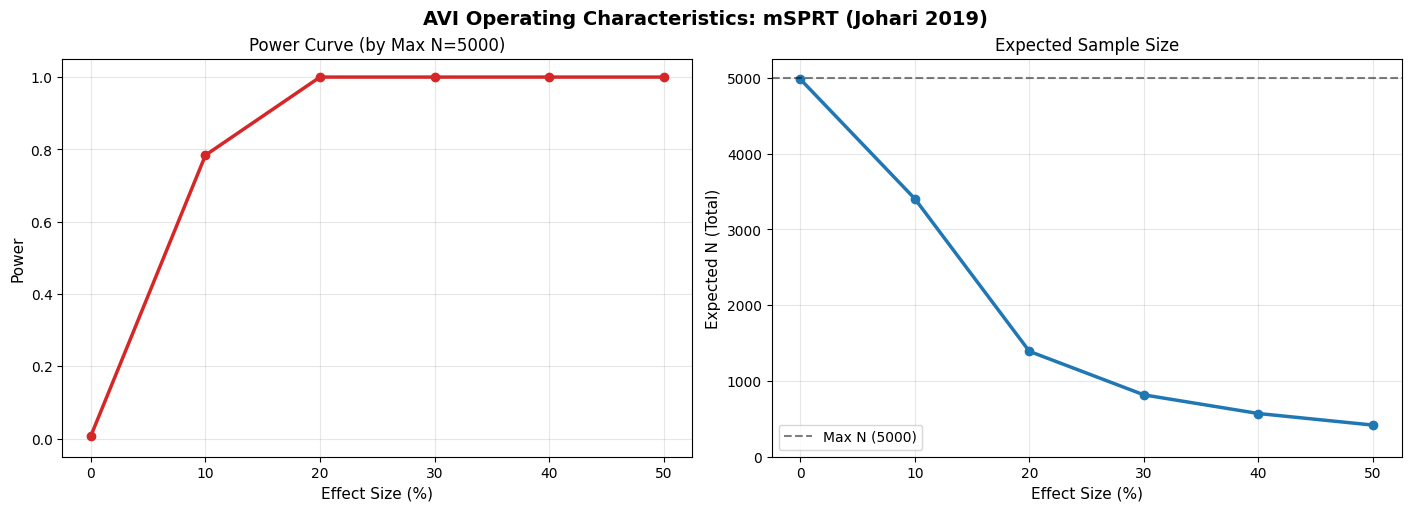

In [2]:
from earlysign.methods.AVI.reporting import visualize_avi_design

visualize_avi_design(protocol, effect_sizes=[0.0, 10.0, 20.0, 30.0, 40.0, 50.0])

## 2. Continuous Monitoring

We can update the results as frequently as data becomes available.

In [3]:
p_c, p_t = 0.10, 0.15
batch_size = 100

print("Starting monitoring...")
for i in range(1, 21):  # Simulated 20 small batches
    batch = [
        BinomialArmData(
            total=batch_size, success=np.random.binomial(batch_size, p_c), arm="C"
        ),
        BinomialArmData(
            total=batch_size, success=np.random.binomial(batch_size, p_t), arm="T"
        ),
    ]

    trial.update(batch)
    report = trial.report_progress()

    # Note: AVI reports e_value instead of boundaries
    # 'status' becomes 'stop' if e_value > 1/alpha
    print(f"Batch {i}: N={report['sample_n']}, Status={report['status']}")

    if report["status"] == DecisionStatus.STOP_DETECTED:
        print(">>> E-value crossed threshold! Evidence is sufficient.")
        break

Starting monitoring...
Batch 1: N=200, Status=continue
Batch 2: N=400, Status=continue
Batch 3: N=600, Status=continue
Batch 4: N=800, Status=continue
Batch 5: N=1000, Status=continue
Batch 6: N=1200, Status=continue
Batch 7: N=1400, Status=continue
Batch 8: N=1600, Status=continue
Batch 9: N=1800, Status=stop_detected
>>> E-value crossed threshold! Evidence is sufficient.


In `earlysign`, mSPRT tracking generates **Always Valid Confidence Bounds** around the trajectory. If the effect estimate exceeds these shrinking confidence bounds, it guarantees that the underlying E-value has exceeded $1/\alpha$, and we stop.

{'summary': None, 'figure': <Figure size 1000x600 with 1 Axes>}
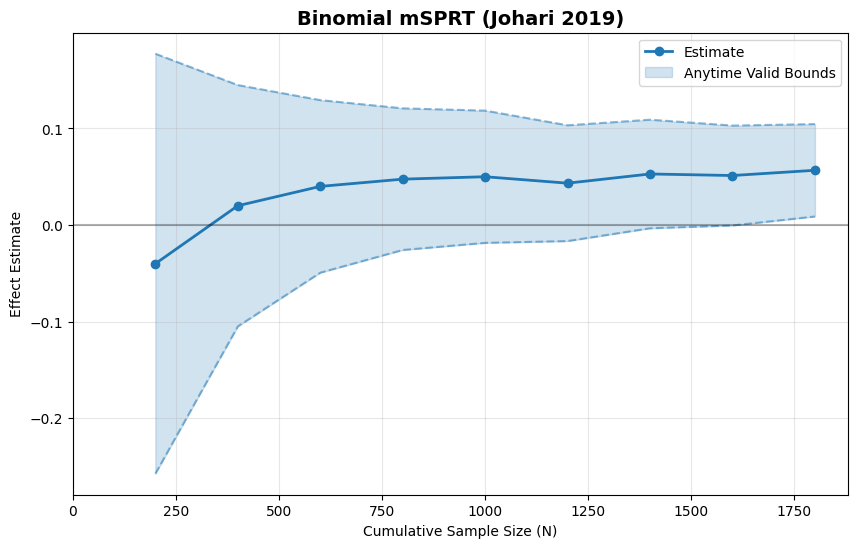

In [4]:
import matplotlib.pyplot as plt
from earlysign.methods.AVI.reporting import plot_avi_trajectory

# Reconstruct the history of the experiment from the ledger
plot_avi_trajectory(ledger, title="Binomial mSPRT (Johari 2019)")

## 4. Summary

- **E-processes**: Allow for true continuous monitoring without alpha-spending "looks".
- **Peeking is Safe**: No penalty for checking the results after every user interaction.
- **Efficiency**: Often detect strong signals faster than fixed-look GSD.

Next, we will look at **Confidence Sequences**, which allow us to report "live" confidence intervals that are valid even under peeking.